In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:
from src.utils.nb_run_logger import NBRunLogger
from pathlib import Path

NOTEBOOK_PATH = Path(r"./NOMBRE_DE_ESTE_NOTEBOOK.ipynb")  # <-- ajusta

seed = 0
run_logger = NBRunLogger("ho", "DV", seed=seed, tag="ho_DV_bq_layered_e1500_w300_8q_2l")  # <-- cambia box/DV según notebook

# Guardado automático de figuras aunque NO haya plt.show()
run_logger.enable_autosave_figures_each_cell()

print("RUN_DIR:", run_logger.run_dir.resolve())
print("FIG_DIR:", run_logger.fig_dir.resolve())
print("ART_DIR:", run_logger.art_dir.resolve())


RUN_DIR: C:\Users\mateo garcia\Downloads\repo\QPINNs-2026\results\ho\DV\20260307-083527_seed0_ho_DV_bq_layered_e1500_w300_8q_2l
FIG_DIR: C:\Users\mateo garcia\Downloads\repo\QPINNs-2026\results\ho\DV\20260307-083527_seed0_ho_DV_bq_layered_e1500_w300_8q_2l\figures
ART_DIR: C:\Users\mateo garcia\Downloads\repo\QPINNs-2026\results\ho\DV\20260307-083527_seed0_ho_DV_bq_layered_e1500_w300_8q_2l\artifacts


In [3]:
import torch
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype  = "float32"   # DVPDESolver/DVQuantumLayer trabajan más estable así en tu repo

torch.manual_seed(0)
if device == "cuda":
    torch.cuda.manual_seed_all(0)

print("device:", device, "| dtype:", dtype)


device: cpu | dtype: float32


In [4]:
import importlib

import src.trainer.schrodinger_train as sch_train
import src.nn.DVPDESolver as dv_solver_mod

importlib.reload(sch_train)
importlib.reload(dv_solver_mod)

from src.trainer.schrodinger_train import train
from src.nn.DVPDESolver import DVPDESolver

from src.problems.schrodinger import build_eq_params, sanity_check
from src.problems.schrodinger.problem import build_problem
from src.utils.logger import Logging


In [5]:
eq_params = build_eq_params(
    "ho",
    L=3.0,          # dominio truncado [-L, L]
    T=0.2,
    mass=1.0,
    hbar=1.0,
    omega=1.0,
    n_level=0,      # prueba n=1 primero
    num_grid=800,
)

print("eq_params:", eq_params)
print("sanity:", sanity_check(eq_params, device=device))


eq_params: {'example': 'ho', 'L': 3.0, 'T': 0.2, 'mass': 1.0, 'hbar': 1.0, 'n_level': 0, 'x_min': -3.0, 'x_max': 3.0, 'omega': 1.0, 'V0': 50.0, 'barrier_width': 0.6, 'x_center': 1.5, 'num_grid': 800}
sanity: {'V_min': 0.00011363349410368691, 'V_max': 4.5, 'psi0_norm': 0.4072223073869094, 'psiT_norm': 0.4072223073869094}


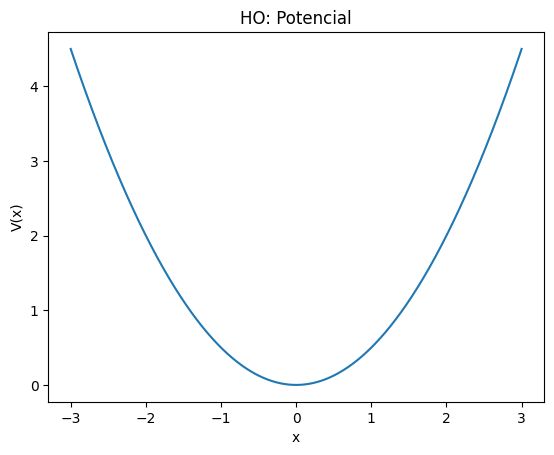

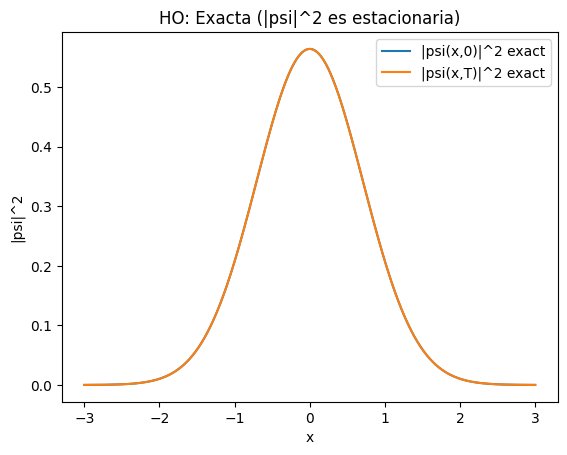

In [6]:
pb = build_problem(
    eq_params,
    device=torch.device(device),
    dtype=torch.float32 if "32" in dtype else torch.float64
)

x = torch.linspace(pb["x_min"], pb["x_max"], 1200, device=device, dtype=pb["dtype"]).reshape(-1, 1)
t0 = torch.zeros_like(x)
tT = torch.full_like(x, pb["T"])

with torch.no_grad():
    V = pb["potential_fn"](t0, x)
    r0,i0,_ = pb["exact"](pb["n_level"], t0, x)
    rT,iT,_ = pb["exact"](pb["n_level"], tT, x)

x_cpu = x.detach().cpu().numpy().flatten()
V_cpu = V.detach().cpu().numpy().flatten()
p0_cpu = (r0**2 + i0**2).detach().cpu().numpy().flatten()
pT_cpu = (rT**2 + iT**2).detach().cpu().numpy().flatten()

plt.figure()
plt.plot(x_cpu, V_cpu)
plt.xlabel("x"); plt.ylabel("V(x)")
plt.title("HO: Potencial")
plt.show()

plt.figure()
plt.plot(x_cpu, p0_cpu, label="|psi(x,0)|^2 exact")
plt.plot(x_cpu, pT_cpu, label="|psi(x,T)|^2 exact")
plt.legend()
plt.xlabel("x"); plt.ylabel("|psi|^2")
plt.title("HO: Exacta (|psi|^2 es estacionaria)")
plt.show()


In [7]:
args = {
    "eq_params": eq_params,
    "device": device,
    "dtype": dtype,
    "problem": "schrodinger",
    "dv_batching": True,
    "pde_chunk_size": 128,
    "dv_batching_mode": "broadcast",
    


    # training
    "epochs": 1500,        # smoke test (sube luego a 1500-3000)
    "lr": 1e-3,
    "batch_size": 64,
    "print_every": 1,

    # pesos (HO suele ir bien con esto)
    "w_pde": 1.0,
    "w_bc":  1.0,         # cola ~0 en bordes del dominio truncado
    "w_ic":  200.0,
    "w_norm": 5.0,
    "w_pde_i": 10.0,
    "w_ic_i": 5.0,
    

    "warmup_epochs": 300,
    "ic_grid": True,
    "N_norm": 400,
    "N_val": 400,

    # DV (circuito)
    "num_qubits": 8,
    "num_quantum_layers": 2,
    "shots": None,        # requerido por el layer aunque default.qubit no lo use
    "noise": False,
    "encoding": "angle",
    "q_ansatz": "layered_circuit", # options: "alternating_layer_tdcnot", farhi , sim_circ_15 ,sim_circ_19, sim_circ_5, layered_circuit

    # red híbrida (ojo: en DVPDESolver solo usa [-2] y [-1])
    "classic_network": [2, 64, 2],   # input=2 (t,x), hidden=64, output=2 (Re,Im)
}

from pathlib import Path
ckpt_dir = Path(run_logger.run_dir) / "checkpoints"
logger = Logging(str(ckpt_dir), f"ho_DV_seed")
model = DVPDESolver(args, logger, device=torch.device(device))
model.args = args

# opcional: no dibujar el circuito cada corrida (ahorra tiempo)
model.draw_quantum_circuit_flag = False

print("DV model built.")


DV model built.


In [8]:
run_logger.log_config(eq_params=eq_params, args=args)


In [9]:
pc = run_logger.log_param_count(model)
print("Trainable params:", pc)


Trainable params: {'total': 1482, 'quantum': 64, 'classical': 1418}


In [10]:
param_dtype = next(model.parameters()).dtype
t_test = torch.rand(8, 1, device=device, dtype=param_dtype) * eq_params["T"]
x_test = (torch.rand(8, 1, device=device, dtype=param_dtype) * (eq_params["x_max"] - eq_params["x_min"]) + eq_params["x_min"])
y = model(torch.cat([t_test, x_test], dim=1))

print("forward ok ->", y.shape, y.dtype, y.device)


forward ok -> torch.Size([8, 2]) torch.float32 cpu


QNode encontrado en quantum_layer.circuit
0: ─╭AngleEmbedding(M0)──RZ(0.07)───RX(0.05)──╭||─╭●───────────────────╭X─╭||──RX(-0.40) ···
1: ─├AngleEmbedding(M0)──RZ(-0.63)──RX(0.07)──├||─╰X─╭●────────────────│──├||──RX(-0.15) ···
2: ─├AngleEmbedding(M0)──RZ(0.07)───RX(-0.25)─├||────╰X─╭●─────────────│──├||──RX(0.19)─ ···
3: ─├AngleEmbedding(M0)──RZ(0.46)───RX(0.45)──├||───────╰X─╭●──────────│──├||──RX(0.11)─ ···
4: ─├AngleEmbedding(M0)──RZ(-0.05)──RX(0.05)──├||──────────╰X─╭●───────│──├||──RX(0.17)─ ···
5: ─├AngleEmbedding(M0)──RZ(0.35)───RX(0.23)──├||─────────────╰X─╭●────│──├||──RX(-0.20) ···
6: ─├AngleEmbedding(M0)──RZ(0.29)───RX(-0.23)─├||────────────────╰X─╭●─│──├||──RX(0.14)─ ···
7: ─╰AngleEmbedding(M0)──RZ(-0.09)──RX(0.32)──╰||───────────────────╰X─╰●─╰||──RX(-0.08) ···

0: ··· ──RZ(0.12)───RZ(0.28)───RX(0.49)──╭||─╭●───────────────────╭X─╭||──RX(0.24)───RZ(-0.26)─┤ ···
1: ··· ──RZ(0.32)───RZ(-0.44)──RX(-0.14)─├||─╰X─╭●────────────────│──├||──RX(-0.04)──RZ(0.55)──┤ ···
2: ··· ──RZ

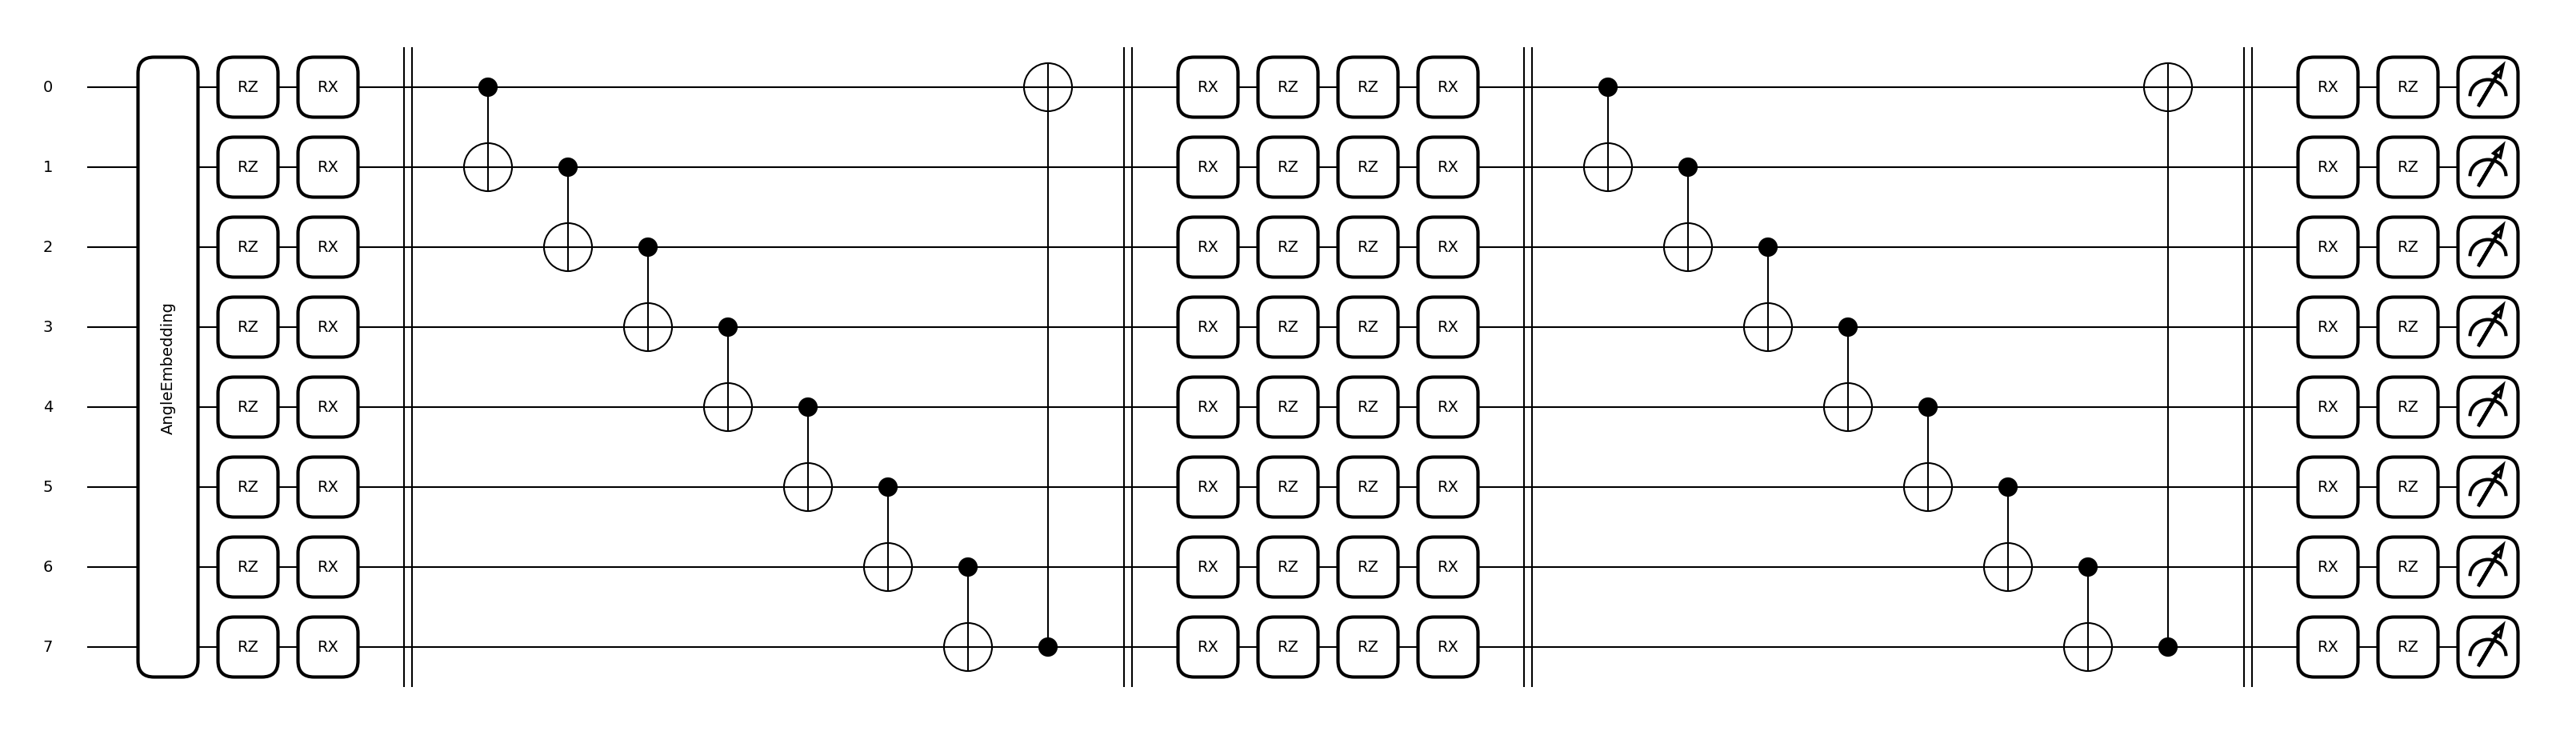

In [11]:
import torch
import pennylane as qml
import matplotlib.pyplot as plt

ql = model.quantum_layer

# Encontrar el QNode (ya viste que está en quantum_layer.circuit)
qnode = getattr(ql, "qnode", None)
if qnode is None:
    for name, val in vars(ql).items():
        if isinstance(val, qml.QNode):
            print(f"QNode encontrado en quantum_layer.{name}")
            qnode = val
            break
if qnode is None:
    raise RuntimeError("No encontré un QNode dentro de model.quantum_layer")

# Input para dibujar (ajusta longitud según tu circuito)
dev = next(model.parameters()).device
dt  = next(model.parameters()).dtype

# Prueba con 4 (tu num_qubits=4); si falla, baja a 2.
n = model.args.get("num_qubits", 4) if hasattr(model, "args") else 4
x_draw = torch.zeros(n, device=dev, dtype=dt)
if n >= 2:
    x_draw[0] = 0.0  # t
    x_draw[1] = 0.0  # x

# 1) ASCII
try:
    drawer_txt = qml.draw(qnode)     # <- sin expansion_strategy
    print(drawer_txt(x_draw))
except Exception as e:
    print("No pude dibujar en ASCII con ese x_draw:", repr(e))
    print("Probando con vector de 2 entradas...")
    x2 = torch.tensor([0.0, 0.0], device=dev, dtype=dt)
    drawer_txt = qml.draw(qnode)
    print(drawer_txt(x2))

# 2) Figura (matplotlib)
try:
    drawer_fig = qml.draw_mpl(qnode) # <- sin expansion_strategy
    fig, ax = drawer_fig(x_draw)
    plt.show()
except Exception as e:
    print("No pude dibujar con draw_mpl con ese x_draw:", repr(e))
    print("Probando con vector de 2 entradas...")
    x2 = torch.tensor([0.0, 0.0], device=dev, dtype=dt)
    drawer_fig = qml.draw_mpl(qnode)
    fig, ax = drawer_fig(x2)
    plt.show()


In [12]:
import logging, sys
from pathlib import Path

def force_live_logging(log_file: Path, level=logging.INFO):
    log_file.parent.mkdir(parents=True, exist_ok=True)
    logging.disable(logging.NOTSET)

    logging.basicConfig(
        level=level,
        format="%(levelname)s:%(name)s:%(message)s",
        handlers=[
            logging.StreamHandler(sys.stdout),
            logging.FileHandler(log_file, encoding="utf-8"),
        ],
        force=True,
    )

    for name in ["src.utils.logger", "src.trainer.schrodinger_train"]:
        lg = logging.getLogger(name)
        lg.setLevel(level)
        lg.propagate = True
        lg.disabled = False

    sys.stdout.flush()

force_live_logging(run_logger.art_dir / "python.log")


In [13]:
import logging
lg = logging.getLogger("src.utils.logger")
lg.handlers.clear()
lg.propagate = True
lg.disabled = False
lg.setLevel(logging.INFO)


In [14]:
train(model, N_f=500, N_b=128, N_0=260)


INFO:src.utils.logger:It: 1, Loss: 1.279e+02, Loss_res: 7.075e-01,  Loss_bcs: 5.477e-02, Loss_ut_ics: 6.393e-01, Loss_norm: 1.993e-03, Loss_gauge: 0.000e+00, w_pde: 3.33e-03, L^2_error: 1.799e+00, lr: 1.000e-03, Time: 1.13e+01
INFO:src.utils.logger:Model state saved to results\ho\DV\20260307-083527_seed0_ho_DV_bq_layered_e1500_w300_8q_2l\checkpoints\2026-03-07_08-35-50-695897_ho_DV_seed\model.pth
INFO:src.utils.logger:Model weights saved to results\ho\DV\20260307-083527_seed0_ho_DV_bq_layered_e1500_w300_8q_2l\checkpoints\2026-03-07_08-35-50-695897_ho_DV_seed\model_weights.pth
INFO:src.utils.logger:It: 2, Loss: 1.062e+02, Loss_res: 4.544e-01,  Loss_bcs: 3.168e-02, Loss_ut_ics: 5.289e-01, Loss_norm: 8.640e-02, Loss_gauge: 0.000e+00, w_pde: 6.67e-03, L^2_error: 1.653e+00, lr: 1.000e-03, Time: 2.21e+01
INFO:src.utils.logger:Model state saved to results\ho\DV\20260307-083527_seed0_ho_DV_bq_layered_e1500_w300_8q_2l\checkpoints\2026-03-07_08-35-50-695897_ho_DV_seed\model.pth
INFO:src.utils.lo

In [15]:
meta = run_logger.log_histories(model)
print("history_meta:", meta)

parsed = run_logger.parse_schrodinger_train_log()
print("Puntos parseados del log:", len(parsed["it"]))
print("Último it/loss/l2:", parsed["it"][-1], parsed["loss"][-1], parsed["l2"][-1])


history_meta: {'loss_history_len': 1500, 'l2_rel_history_len': 1500, 'loss_history_type': "<class 'list'>", 'l2_rel_history_type': "<class 'list'>"}
Puntos parseados del log: 1500
Último it/loss/l2: 1500 0.00442 0.01805


L2_rel(T): 0.01804422028362751


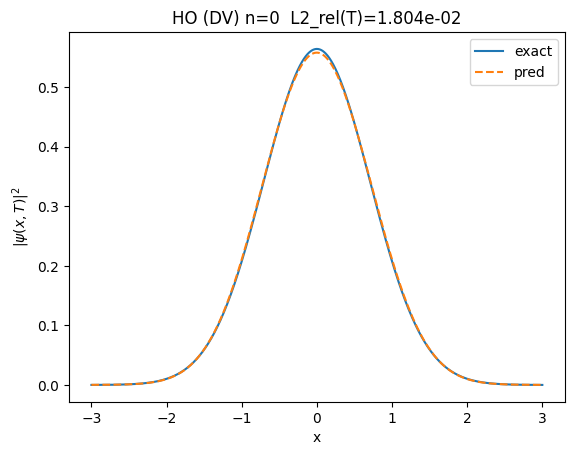

In [16]:
import torch
import matplotlib.pyplot as plt
from src.problems.schrodinger.problem import build_problem

def normalize_dtype(dt):
    if isinstance(dt, torch.dtype):
        return dt
    if isinstance(dt, str):
        dt = dt.lower()
        if "32" in dt:
            return torch.float32
        if "64" in dt:
            return torch.float64
    raise ValueError(f"dtype no reconocido: {dt} ({type(dt)})")

pb = build_problem(
    eq_params,
    device=torch.device(device),
    dtype=normalize_dtype(dtype)
)

x = torch.linspace(pb["x_min"], pb["x_max"], 1200, device=pb["device"], dtype=pb["dtype"]).reshape(-1, 1)
t = torch.full_like(x, float(pb["T"]))

with torch.no_grad():
    pred = model(torch.cat([t, x], dim=1))
    pr, pi = pred[:, 0:1], pred[:, 1:2]
    er, ei, _ = pb["exact"](pb["n_level"], t, x)

    l2_abs = torch.sqrt(torch.mean((pr-er)**2 + (pi-ei)**2))
    ref = torch.sqrt(torch.mean(er**2 + ei**2)) + 1e-12
    l2_rel = (l2_abs / ref).item()

print("L2_rel(T):", l2_rel)

prob_pred  = (pr**2 + pi**2).detach().cpu().numpy().flatten()
prob_exact = (er**2 + ei**2).detach().cpu().numpy().flatten()
x_cpu      = x.detach().cpu().numpy().flatten()

plt.figure()
plt.plot(x_cpu, prob_exact, label="exact")
plt.plot(x_cpu, prob_pred,  "--", label="pred")
plt.legend()
plt.xlabel("x"); plt.ylabel(r"$|\psi(x,T)|^2$")
plt.title(f"HO (DV) n={eq_params['n_level']}  L2_rel(T)={l2_rel:.3e}")
plt.show()



In [17]:
x = torch.linspace(pb["x_min"], pb["x_max"], 1400, device=device, dtype=pb["dtype"]).reshape(-1,1)
t0 = torch.zeros_like(x)
tT = torch.full_like(x, pb["T"])

with torch.no_grad():
    p0 = model(torch.cat([t0, x], dim=1))
    pT = model(torch.cat([tT, x], dim=1))

    prob0 = p0[:,0]**2 + p0[:,1]**2
    probT = pT[:,0]**2 + pT[:,1]**2

    norm0 = torch.trapz(prob0, x.squeeze(-1)).item()
    normT = torch.trapz(probT, x.squeeze(-1)).item()

print("Norm pred t=0:", norm0)
print("Norm pred t=T:", normT)


Norm pred t=0: 0.9996662735939026
Norm pred t=T: 0.9999188780784607


In [18]:
print("broadcast_ok:", getattr(model.quantum_layer, "_broadcast_ok", None))
print("dv_batching_mode:", getattr(model.quantum_layer, "dv_batching_mode", None))


broadcast_ok: True
dv_batching_mode: broadcast


In [19]:
import torch

def count_params(model):
    total = 0
    trainable = 0
    by_block = {}  # desglose por prefijo: preprocessor / quantum_layer / postprocessor / hidden / etc.

    for name, p in model.named_parameters():
        n = p.numel()
        total += n
        if p.requires_grad:
            trainable += n

        block = name.split(".")[0]  # primer prefijo (preprocessor, quantum_layer, postprocessor, etc.)
        by_block.setdefault(block, {"total": 0, "trainable": 0})
        by_block[block]["total"] += n
        if p.requires_grad:
            by_block[block]["trainable"] += n

    return total, trainable, by_block


total, trainable, by_block = count_params(model)

print(f"Total parámetros (incluye no-entrenables): {total:,}")
print(f"Parámetros ENTRENABLES (clásicos + cuánticos): {trainable:,}\n")

print("Desglose por bloque (trainables / total):")
for k, v in sorted(by_block.items(), key=lambda kv: -kv[1]["trainable"]):
    print(f"  - {k:15s}: {v['trainable']:,} / {v['total']:,}")

# si quieres además listar SOLO los tensores entrenables:
print("\nListado de parámetros entrenables:")
for name, p in model.named_parameters():
    if p.requires_grad:
        print(f"  {name:40s} {tuple(p.shape)}  numel={p.numel():,}  dtype={p.dtype}")



Total parámetros (incluye no-entrenables): 1,482
Parámetros ENTRENABLES (clásicos + cuánticos): 1,482

Desglose por bloque (trainables / total):
  - preprocessor   : 712 / 712
  - postprocessor  : 706 / 706
  - quantum_layer  : 64 / 64

Listado de parámetros entrenables:
  preprocessor.0.weight                    (64, 2)  numel=128  dtype=torch.float32
  preprocessor.0.bias                      (64,)  numel=64  dtype=torch.float32
  preprocessor.2.weight                    (8, 64)  numel=512  dtype=torch.float32
  preprocessor.2.bias                      (8,)  numel=8  dtype=torch.float32
  quantum_layer.params                     (2, 32)  numel=64  dtype=torch.float32
  postprocessor.0.weight                   (64, 8)  numel=512  dtype=torch.float32
  postprocessor.0.bias                     (64,)  numel=64  dtype=torch.float32
  postprocessor.2.weight                   (2, 64)  numel=128  dtype=torch.float32
  postprocessor.2.bias                     (2,)  numel=2  dtype=torch.float3

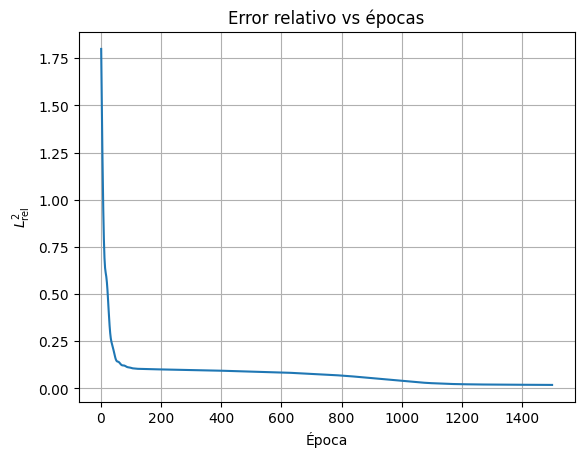

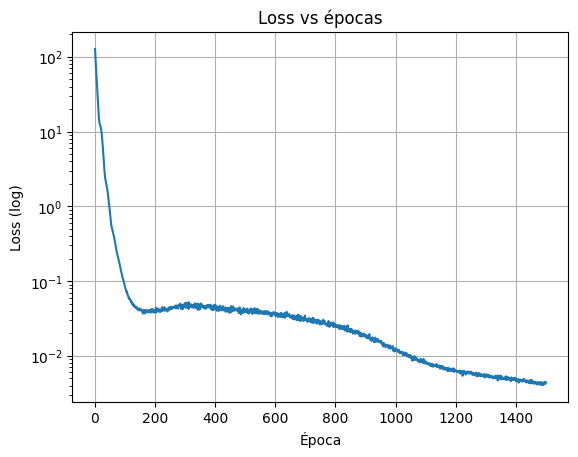

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def get_history(model):
    # intentos comunes (por si el nombre cambia)
    l2_keys = ["l2_rel_history", "l2_history", "l2_error_history"]
    loss_keys = ["loss_history", "losses", "train_loss_history"]

    l2 = None
    for k in l2_keys:
        if hasattr(model, k) and len(getattr(model, k)) > 0:
            l2 = np.array(getattr(model, k), dtype=float)
            break

    loss = None
    for k in loss_keys:
        if hasattr(model, k) and len(getattr(model, k)) > 0:
            loss = np.array(getattr(model, k), dtype=float)
            break

    return loss, l2


loss, l2 = get_history(model)

if loss is None:
    raise AttributeError("No encontré historial de pérdida en el modelo (esperaba model.loss_history).")

if l2 is None:
    raise AttributeError("No encontré historial de error L2 en el modelo (esperaba model.l2_rel_history).")

epochs_loss = np.arange(1, len(loss) + 1)
epochs_l2   = np.arange(1, len(l2) + 1)

plt.figure()
plt.plot(epochs_l2, l2)
plt.xlabel("Época")
plt.ylabel(r"$L^2_{\mathrm{rel}}$")
plt.title("Error relativo vs épocas")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(epochs_loss, loss)
plt.yscale("log")
plt.xlabel("Época")
plt.ylabel("Loss (log)")
plt.title("Loss vs épocas")
plt.grid(True)
plt.show()



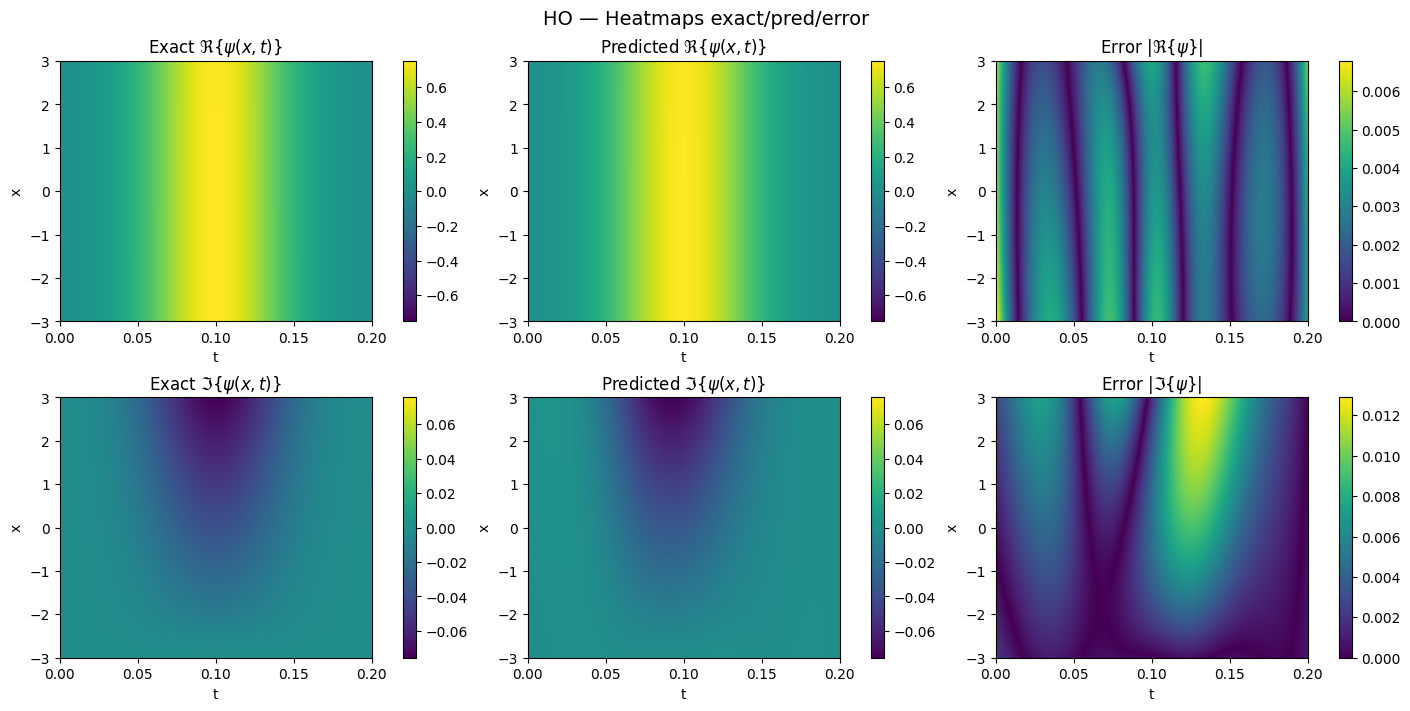

In [21]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Necesario: build_problem para exacta y dominio
from src.problems.schrodinger.problem import build_problem

@torch.no_grad()
def eval_model_in_chunks(model, tx, chunk=512):
    """
    Evalúa model(tx) en trozos para no reventar memoria y para no hacer una sola llamada gigante (útil en DV).
    tx: (N,2)
    """
    model.eval()
    outs = []
    N = tx.shape[0]
    for i in range(0, N, chunk):
        outs.append(model(tx[i:i+chunk]))
    return torch.cat(outs, dim=0)

def plot_heatmaps_exact_pred_error(model, eq_params, Nt=120, Nx=220, chunk=512):
    device = next(model.parameters()).device
    dtype  = next(model.parameters()).dtype

    problem = build_problem(eq_params, device=device, dtype=dtype)
    T = float(problem["T"])
    x_min = float(problem["x_min"])
    x_max = float(problem["x_max"])
    n_level = int(problem["n_level"])

    # mallas
    t = torch.linspace(0.0, T, Nt, device=device, dtype=dtype)
    x = torch.linspace(x_min, x_max, Nx, device=device, dtype=dtype)
    TT, XX = torch.meshgrid(t, x, indexing="ij")  # (Nt,Nx)

    t_flat = TT.reshape(-1, 1)
    x_flat = XX.reshape(-1, 1)
    tx = torch.cat([t_flat, x_flat], dim=1)

    # exacta
    psi_r_ex, psi_i_ex, _ = problem["exact"](n_level, t_flat, x_flat)

    # predicción
    psi_pred = eval_model_in_chunks(model, tx, chunk=chunk)
    psi_r_pr = psi_pred[:, 0:1]
    psi_i_pr = psi_pred[:, 1:2]

    # reshape a (Nt,Nx)
    Re_ex = psi_r_ex.reshape(Nt, Nx).detach().cpu().numpy()
    Im_ex = psi_i_ex.reshape(Nt, Nx).detach().cpu().numpy()
    Re_pr = psi_r_pr.reshape(Nt, Nx).detach().cpu().numpy()
    Im_pr = psi_i_pr.reshape(Nt, Nx).detach().cpu().numpy()

    Re_er = np.abs(Re_pr - Re_ex)
    Im_er = np.abs(Im_pr - Im_ex)

    # escalas razonables (simétricas para Re/Im; positivas para error)
    re_max = max(np.max(np.abs(Re_ex)), np.max(np.abs(Re_pr))) + 1e-12
    im_max = max(np.max(np.abs(Im_ex)), np.max(np.abs(Im_pr))) + 1e-12
    re_e_max = np.max(Re_er) + 1e-12
    im_e_max = np.max(Im_er) + 1e-12

    extent = [0.0, T, x_min, x_max]  # x-axis=t, y-axis=x

    fig, axes = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)

    # --- Re row ---
    im0 = axes[0,0].imshow(Re_ex, origin="lower", aspect="auto", extent=extent, vmin=-re_max, vmax=re_max)
    axes[0,0].set_title(r"Exact $\Re\{\psi(x,t)\}$")
    plt.colorbar(im0, ax=axes[0,0], fraction=0.046)

    im1 = axes[0,1].imshow(Re_pr, origin="lower", aspect="auto", extent=extent, vmin=-re_max, vmax=re_max)
    axes[0,1].set_title(r"Predicted $\Re\{\psi(x,t)\}$")
    plt.colorbar(im1, ax=axes[0,1], fraction=0.046)

    im2 = axes[0,2].imshow(Re_er, origin="lower", aspect="auto", extent=extent, vmin=0.0, vmax=re_e_max)
    axes[0,2].set_title(r"Error $|\Re\{\psi\}|$")
    plt.colorbar(im2, ax=axes[0,2], fraction=0.046)

    # --- Im row ---
    im3 = axes[1,0].imshow(Im_ex, origin="lower", aspect="auto", extent=extent, vmin=-im_max, vmax=im_max)
    axes[1,0].set_title(r"Exact $\Im\{\psi(x,t)\}$")
    plt.colorbar(im3, ax=axes[1,0], fraction=0.046)

    im4 = axes[1,1].imshow(Im_pr, origin="lower", aspect="auto", extent=extent, vmin=-im_max, vmax=im_max)
    axes[1,1].set_title(r"Predicted $\Im\{\psi(x,t)\}$")
    plt.colorbar(im4, ax=axes[1,1], fraction=0.046)

    im5 = axes[1,2].imshow(Im_er, origin="lower", aspect="auto", extent=extent, vmin=0.0, vmax=im_e_max)
    axes[1,2].set_title(r"Error $|\Im\{\psi\}|$")
    plt.colorbar(im5, ax=axes[1,2], fraction=0.046)

    for ax in axes.flat:
        ax.set_xlabel("t")
        ax.set_ylabel("x")

    ex = str(eq_params.get("example", "schrodinger")).upper()
    fig.suptitle(f"{ex} — Heatmaps exact/pred/error", fontsize=14)
    plt.show()

# ---- úsalo así ----
plot_heatmaps_exact_pred_error(model, eq_params, Nt=120, Nx=220, chunk=512)



In [22]:
import json
import csv
from datetime import datetime
from pathlib import Path

import torch

# --- Requiere: model, eq_params, run_logger (y idealmente device/dtype/args si existen) ---
assert "model" in globals(), "No encuentro 'model'. Ejecuta esta celda después de entrenar."
assert "eq_params" in globals(), "No encuentro 'eq_params'."
assert "run_logger" in globals(), "No encuentro 'run_logger'."

# ---------- Utils ----------
def _to_path(x):
    try:
        return Path(x)
    except Exception:
        return Path(str(x))

def _safe_get(d, key, default=None):
    try:
        return d.get(key, default)
    except Exception:
        return default

def _write_json(path: Path, obj: dict):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)

def _model_eval(model, t, x):
    """Soporta model([t,x]) o model(t,x) según tu API."""
    try:
        return model(torch.cat([t, x], dim=1))
    except Exception:
        return model(t, x)

def _l2_rel_prob(prob_pred: torch.Tensor, prob_exact: torch.Tensor, eps: float = 1e-12) -> float:
    num = torch.sqrt(torch.mean((prob_pred - prob_exact) ** 2))
    den = torch.sqrt(torch.mean(prob_exact ** 2)) + eps
    return (num / den).item()

def _find_results_root_from_run_logger(run_logger):
    """Intenta encontrar carpeta 'results' a partir de run_logger.run_dir; si no, usa ./results."""
    run_dir = _to_path(getattr(run_logger, "run_dir", ".")).resolve()
    # caso 1: alguna carpeta padre se llama "results"
    for p in [run_dir] + list(run_dir.parents):
        if p.name.lower() == "results":
            return p
    # caso 2: algún padre contiene una carpeta llamada "results"
    for p in run_dir.parents:
        cand = p / "results"
        if cand.exists() and cand.is_dir():
            return cand
    # fallback
    return (Path(".") / "results").resolve()

def _append_or_update_csv(csv_path: Path, row: dict, key_col: str = "run_dir"):
    """
    Agrega una fila al CSV. Si ya existe una fila con el mismo key_col (p.ej. run_dir), la reemplaza.
    Funciona sin pandas (solo stdlib).
    """
    csv_path.parent.mkdir(parents=True, exist_ok=True)

    rows = []
    cols = list(row.keys())

    if csv_path.exists():
        with open(csv_path, "r", newline="", encoding="utf-8") as f:
            reader = csv.DictReader(f)
            old_cols = reader.fieldnames or []
            cols = list(dict.fromkeys(old_cols + cols))  # unión preservando orden
            for r in reader:
                rows.append(r)

        # filtra si ya existe esa corrida
        new_rows = []
        for r in rows:
            if r.get(key_col, "") != str(row.get(key_col, "")):
                new_rows.append(r)
        rows = new_rows

    # agrega la fila nueva
    # asegura todas las columnas
    row_filled = {c: row.get(c, "") for c in cols}
    rows.append(row_filled)

    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=cols)
        writer.writeheader()
        writer.writerows(rows)

# ---------- Construye pb / exact ----------
from src.problems.schrodinger.problem import build_problem

# dtype/device robusto
device_val = globals().get("device", "cpu")
dev = torch.device(device_val) if not isinstance(device_val, torch.device) else device_val

dtype_str = str(globals().get("dtype", _safe_get(getattr(model, "args", {}), "dtype", "float64")))
torch_dtype = torch.float64 if "64" in dtype_str else torch.float32

pb = build_problem(eq_params, device=dev, dtype=torch_dtype)

# eval grid
num_x = int(_safe_get(eq_params, "num_grid", 800))
x = torch.linspace(pb["x_min"], pb["x_max"], num_x, device=dev, dtype=pb["dtype"]).reshape(-1, 1)

T = float(pb["T"])
t_fracs = [0.0, 0.25, 0.50, 0.75, 1.0]
t_eval = torch.tensor([f * T for f in t_fracs], device=dev, dtype=pb["dtype"]).reshape(-1, 1)

# Detecta exacta
has_exact = ("exact" in pb) and callable(pb["exact"])

series = []
l2_rel_psi_T = None
l2_rel_prob_T = None

with torch.no_grad():
    for ti in t_eval:
        t = ti.repeat(x.shape[0], 1)
        pred = _model_eval(model, t, x)
        pr, pi = pred[:, 0:1], pred[:, 1:2]

        rec = {"t": float(ti.item())}

        if has_exact:
            er, ei, _ = pb["exact"](pb["n_level"], t, x)

            # L2 relativo de psi (Re+Im)
            l2_abs_psi = torch.sqrt(torch.mean((pr - er) ** 2 + (pi - ei) ** 2))
            ref_psi = torch.sqrt(torch.mean(er ** 2 + ei ** 2)) + 1e-12
            rec["l2_rel_psi"] = float((l2_abs_psi / ref_psi).item())

            # L2 relativo de |psi|^2
            prob_pred = pr ** 2 + pi ** 2
            prob_exact = er ** 2 + ei ** 2
            rec["l2_rel_prob"] = float(_l2_rel_prob(prob_pred, prob_exact))

        series.append(rec)

# extrae T
if has_exact and len(series) > 0:
    l2_rel_psi_T = series[-1].get("l2_rel_psi", None)
    l2_rel_prob_T = series[-1].get("l2_rel_prob", None)

# Boundary check (genérico: xmin/xmax)
ts = torch.linspace(0.0, T, 20, device=dev, dtype=pb["dtype"]).reshape(-1, 1)
x_min = torch.full_like(ts, float(pb["x_min"]))
x_max = torch.full_like(ts, float(pb["x_max"]))

with torch.no_grad():
    psi_min = _model_eval(model, ts, x_min)
    psi_max = _model_eval(model, ts, x_max)

bdry_xmin = torch.sqrt(psi_min[:, 0] ** 2 + psi_min[:, 1] ** 2).max().item()
bdry_xmax = torch.sqrt(psi_max[:, 0] ** 2 + psi_max[:, 1] ** 2).max().item()

# ---------- Metadata (reutilizable en todos) ----------
args = globals().get("args", getattr(model, "args", {})) or {}
potential = str(getattr(run_logger, "problem", _safe_get(eq_params, "potential", _safe_get(eq_params, "name", "unknown"))))
solver = str(getattr(run_logger, "solver", getattr(run_logger, "solver_type", _safe_get(args, "solver_type", "unknown"))))
seed = getattr(run_logger, "seed", _safe_get(args, "seed", None))
tag = getattr(run_logger, "tag", _safe_get(args, "tag", ""))

run_dir = _to_path(getattr(run_logger, "run_dir", ".")).resolve()
art_dir = _to_path(getattr(run_logger, "art_dir", run_dir / "artifacts")).resolve()

# parámetros entrenables (total)
n_params_total = int(sum(p.numel() for p in model.parameters() if p.requires_grad))

# si existe una función de conteo detallado (DV notebooks), úsala
n_params_quantum = ""
n_params_classical = ""
if "count_trainable_params" in globals() and callable(globals()["count_trainable_params"]):
    try:
        out = globals()["count_trainable_params"](model)
        if isinstance(out, dict):
            n_params_total = int(out.get("total", n_params_total))
            n_params_quantum = int(out.get("quantum", ""))
            n_params_classical = int(out.get("classical", ""))
        elif isinstance(out, (tuple, list)) and len(out) >= 3:
            n_params_total = int(out[0])
            n_params_quantum = int(out[1])
            n_params_classical = int(out[2])
    except Exception:
        pass

# identifica arquitectura / ansatz / encoding (sin forzar que existan)
classic_network = _safe_get(args, "classic_network", "")
num_qubits = _safe_get(args, "num_qubits", "")
num_layers = _safe_get(args, "num_quantum_layers", _safe_get(args, "num_layers", ""))
q_ansatz = _safe_get(args, "q_ansatz", "")
encoding = _safe_get(args, "encoding", "")

arch_repr = ""
if q_ansatz or num_qubits or num_layers:
    arch_repr = f"DV(q={num_qubits}, L={num_layers}, ansatz={q_ansatz}, enc={encoding}, classic={classic_network})"
else:
    arch_repr = f"PINN(classic={classic_network})"

# epochs/lr y puntos si están disponibles (si no, quedan vacíos)
epochs = _safe_get(args, "epochs", "")
lr = _safe_get(args, "lr", "")
N_f = globals().get("N_f", _safe_get(args, "N_f", ""))
N_b = globals().get("N_b", _safe_get(args, "N_b", ""))
N_0 = globals().get("N_0", _safe_get(args, "N_0", ""))

# ---------- Guardado JSON en artifacts ----------
metrics = {
    "timestamp": datetime.now().isoformat(timespec="seconds"),
    "potential": potential,
    "solver": solver,
    "seed": seed,
    "tag": tag,
    "run_dir": str(run_dir),
    "art_dir": str(art_dir),
    "dtype": dtype_str,
    "device": str(dev),

    "n_params_total": n_params_total,
    "n_params_quantum": n_params_quantum,
    "n_params_classical": n_params_classical,

    "epochs": epochs,
    "lr": lr,
    "N_f": N_f,
    "N_b": N_b,
    "N_0": N_0,

    "arch_repr": arch_repr,
    "classic_network": str(classic_network),
    "num_qubits": str(num_qubits),
    "num_quantum_layers": str(num_layers),
    "q_ansatz": str(q_ansatz),
    "encoding": str(encoding),

    # --- métricas mínimas tesis ---
    "has_exact": bool(has_exact),
    "l2_rel_psi_T": l2_rel_psi_T,
    "l2_rel_prob_T": l2_rel_prob_T,
    "bdry_max_abs_psi_xmin": float(bdry_xmin),
    "bdry_max_abs_psi_xmax": float(bdry_xmax),

    # evidencia temporal
    "series": series,
}

art_dir.mkdir(parents=True, exist_ok=True)
metrics_path = art_dir / "metrics_min.json"
_write_json(metrics_path, metrics)

# ---------- CSV global reutilizable ----------
results_root = _find_results_root_from_run_logger(run_logger)
summary_csv = results_root / "summary" / "summary_runs.csv"

row = {
    "timestamp": metrics["timestamp"],
    "potential": metrics["potential"],
    "solver": metrics["solver"],
    "seed": metrics["seed"],
    "tag": metrics["tag"],
    "run_dir": metrics["run_dir"],
    "n_params_total": metrics["n_params_total"],
    "n_params_quantum": metrics["n_params_quantum"],
    "n_params_classical": metrics["n_params_classical"],
    "epochs": metrics["epochs"],
    "lr": metrics["lr"],
    "N_f": metrics["N_f"],
    "N_b": metrics["N_b"],
    "N_0": metrics["N_0"],
    "dtype": metrics["dtype"],
    "device": metrics["device"],
    "arch_repr": metrics["arch_repr"],
    "q_ansatz": metrics["q_ansatz"],
    "encoding": metrics["encoding"],
    "num_qubits": metrics["num_qubits"],
    "num_quantum_layers": metrics["num_quantum_layers"],
    "classic_network": metrics["classic_network"],
    "has_exact": metrics["has_exact"],
    "l2_rel_psi_T": metrics["l2_rel_psi_T"],
    "l2_rel_prob_T": metrics["l2_rel_prob_T"],
    "bdry_max_abs_psi_xmin": metrics["bdry_max_abs_psi_xmin"],
    "bdry_max_abs_psi_xmax": metrics["bdry_max_abs_psi_xmax"],
    "metrics_json": str(metrics_path),
}

_append_or_update_csv(summary_csv, row, key_col="run_dir")

print("\n[OK] Guardado:")
print(" - metrics_min.json:", metrics_path.resolve())
print(" - summary CSV     :", summary_csv.resolve())
print("\nResumen (t=T):")
print(" - L2_rel(psi)      :", row["l2_rel_psi_T"])
print(" - L2_rel(|psi|^2)  :", row["l2_rel_prob_T"])
print(" - max|psi|(xmin)   :", row["bdry_max_abs_psi_xmin"])
print(" - max|psi|(xmax)   :", row["bdry_max_abs_psi_xmax"])


[OK] Guardado:
 - metrics_min.json: C:\Users\mateo garcia\Downloads\repo\QPINNs-2026\results\ho\DV\20260307-083527_seed0_ho_DV_bq_layered_e1500_w300_8q_2l\artifacts\metrics_min.json
 - summary CSV     : C:\Users\mateo garcia\Downloads\repo\QPINNs-2026\results\summary\summary_runs.csv

Resumen (t=T):
 - L2_rel(psi)      : 0.018046682700514793
 - L2_rel(|psi|^2)  : 0.008653389289975166
 - max|psi|(xmin)   : 0.015269514173269272
 - max|psi|(xmax)   : 0.013579574413597584


FIG_DIR: C:\Users\mateo garcia\Downloads\repo\QPINNs-2026\results\ho\DV\20260307-083527_seed0_ho_DV_bq_layered_e1500_w300_8q_2l\figures


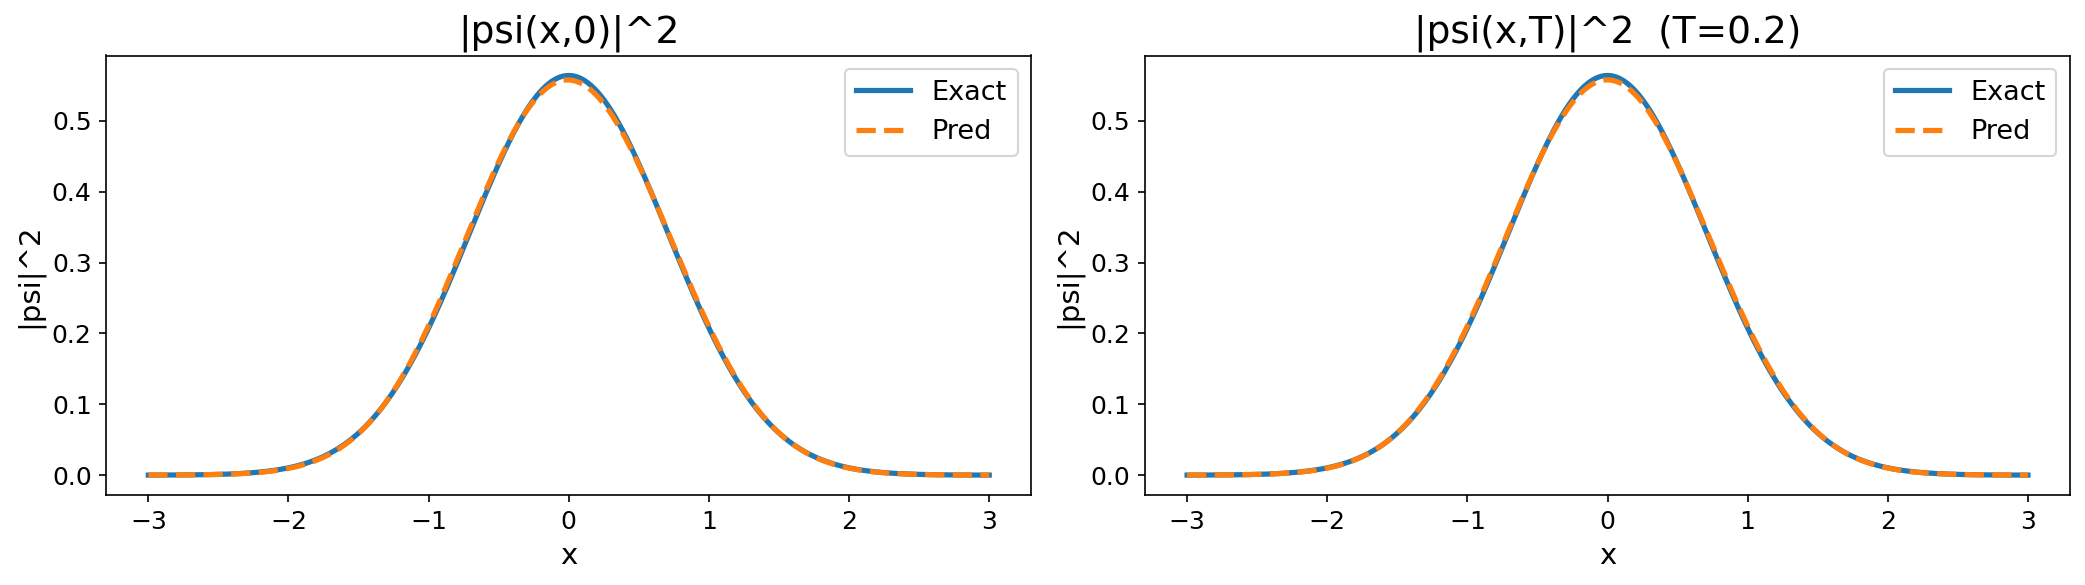

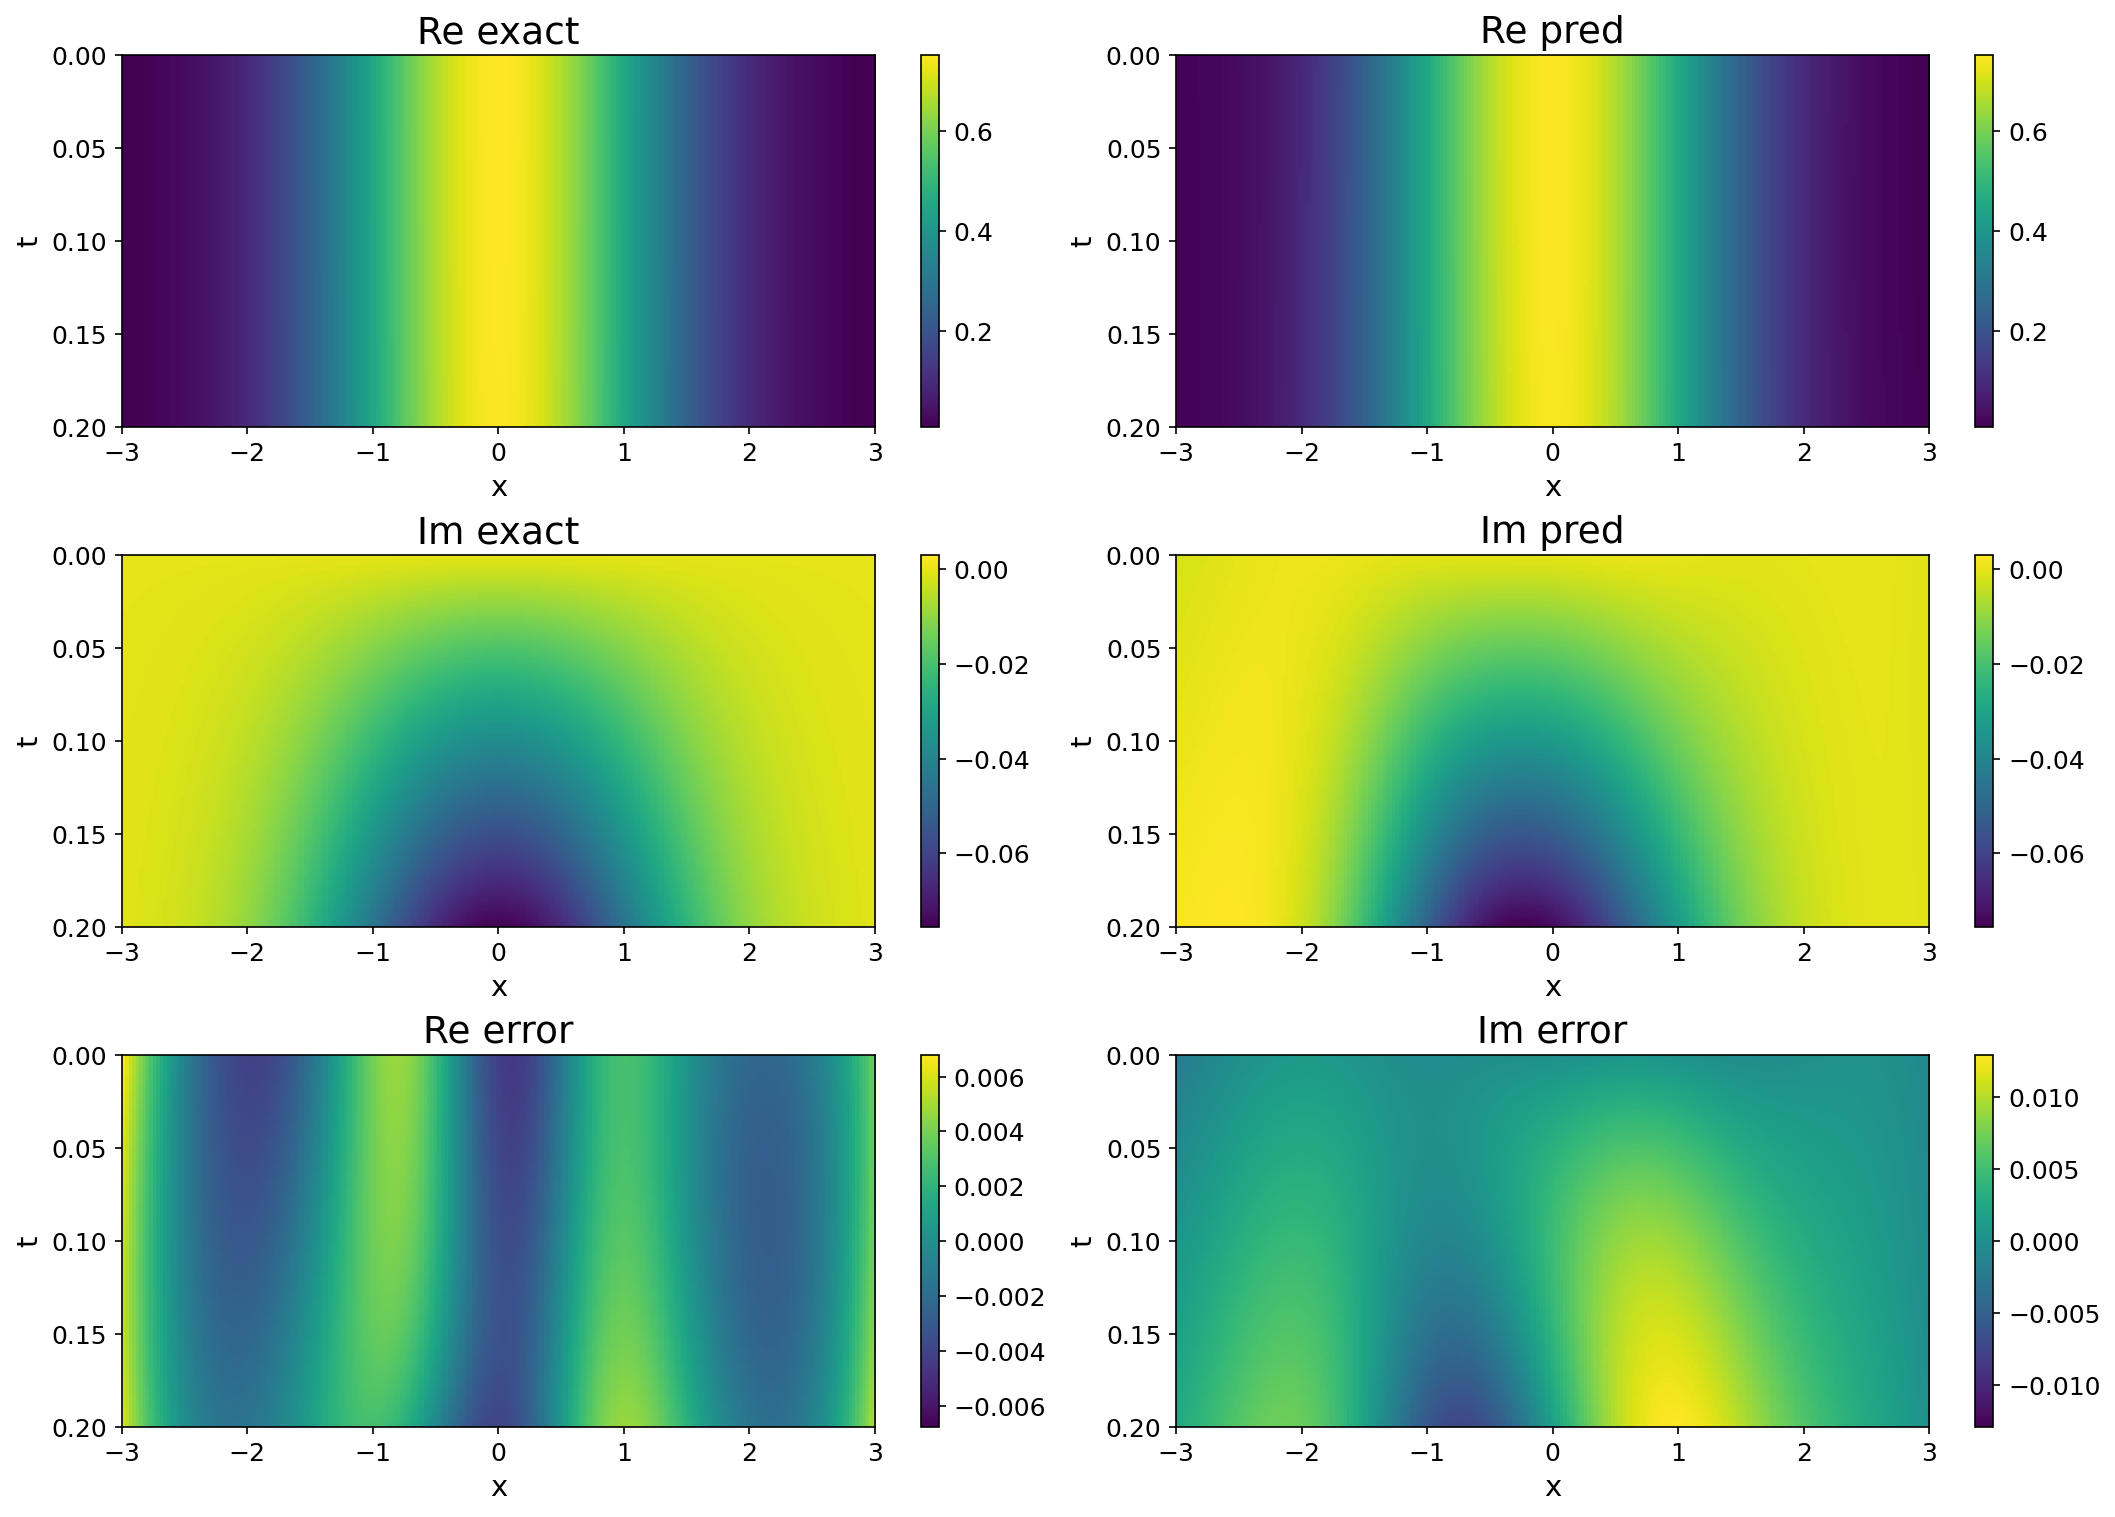

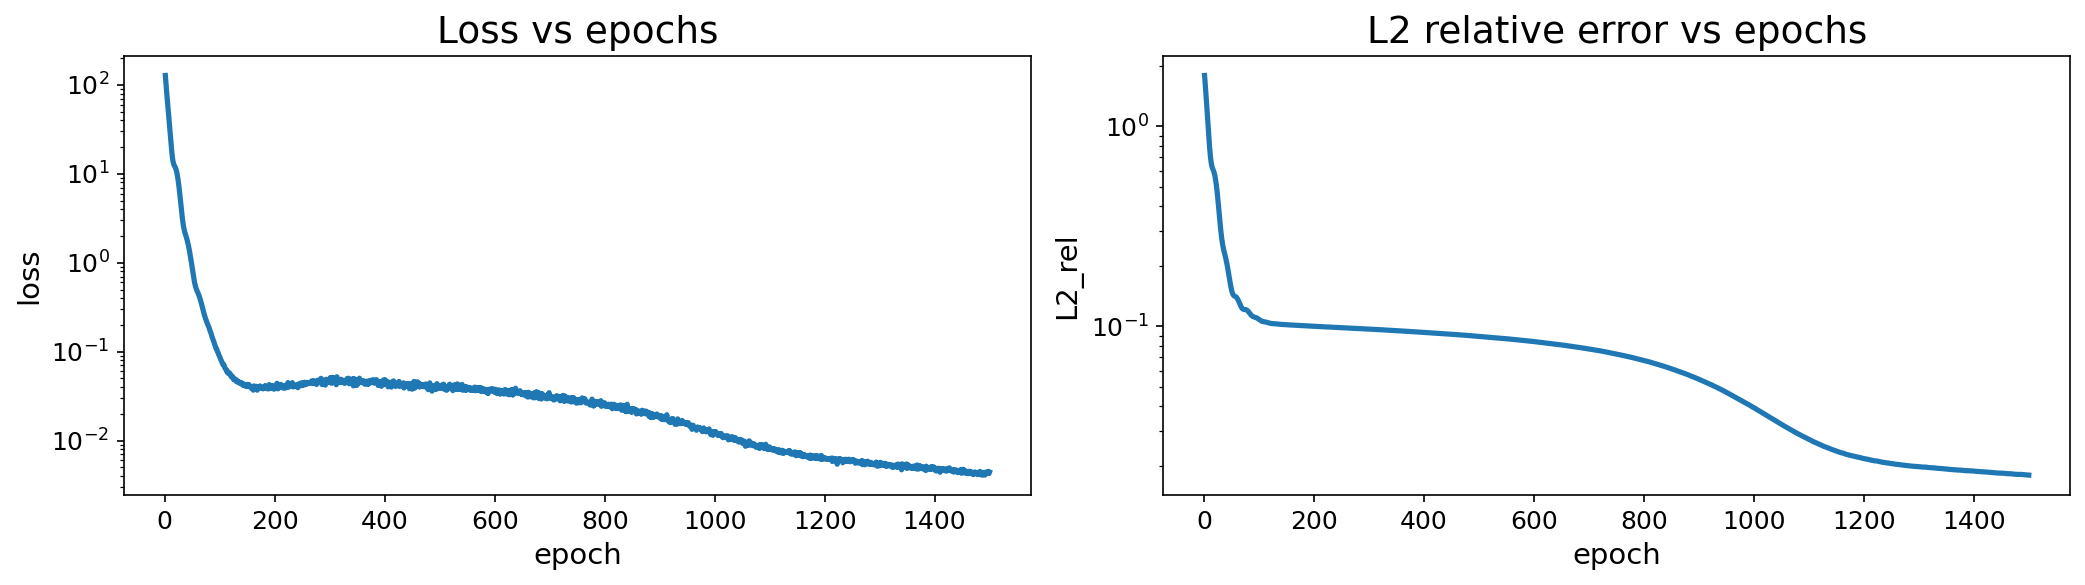

✅ Figuras generadas y guardadas en: C:\Users\mateo garcia\Downloads\repo\QPINNs-2026\results\ho\DV\20260307-083527_seed0_ho_DV_bq_layered_e1500_w300_8q_2l\figures


In [23]:
# ===================== POST-TRAIN FIGURES (una sola celda) =====================
# Requiere que ya existan: model, eq_params  (y opcionalmente run_logger)
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

from src.problems.schrodinger.problem import build_problem

# ---------- Estilo (similar al de tus figuras) ----------
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.titlesize": 18,
    "axes.labelsize": 14,
    "legend.fontsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "lines.linewidth": 2.5,
})

# ---------- Directorio de guardado (usa run_logger si existe) ----------
def _infer_fig_dir():
    if "run_logger" in globals() and hasattr(run_logger, "fig_dir"):
        p = Path(run_logger.fig_dir)
    elif "run_logger" in globals() and hasattr(run_logger, "run_dir"):
        p = Path(run_logger.run_dir) / "figures"
    else:
        p = Path("./results/figures")
    p.mkdir(parents=True, exist_ok=True)
    return p

FIG_DIR = _infer_fig_dir()
print("FIG_DIR:", FIG_DIR.resolve())

def _save_fig(fig, name: str):
    path = FIG_DIR / name
    fig.savefig(path, bbox_inches="tight")
    return path

@torch.no_grad()
def _eval_model_in_chunks(model, tx, chunk=512):
    """Evalúa model(tx) por chunks (importante para DV). tx: (N,2)"""
    model.eval()
    outs = []
    N = tx.shape[0]
    for i in range(0, N, chunk):
        outs.append(model(tx[i:i+chunk]))
    return torch.cat(outs, dim=0)

def _get_history(model):
    l2_keys   = ["l2_rel_history", "l2_history", "l2_error_history"]
    loss_keys = ["loss_history", "losses", "train_loss_history"]

    l2 = None
    for k in l2_keys:
        if hasattr(model, k) and len(getattr(model, k)) > 0:
            l2 = np.asarray(getattr(model, k), dtype=float)
            break

    loss = None
    for k in loss_keys:
        if hasattr(model, k) and len(getattr(model, k)) > 0:
            loss = np.asarray(getattr(model, k), dtype=float)
            break

    return loss, l2

# ---------- Construye problema (exacta + dominio) ----------
device = next(model.parameters()).device
dtype  = next(model.parameters()).dtype
pb = build_problem(eq_params, device=device, dtype=dtype)

T      = float(pb["T"])
x_min  = float(pb["x_min"])
x_max  = float(pb["x_max"])
n_lvl  = int(pb["n_level"])

# Tag opcional para nombres (si tienes args en el notebook)
tag = ""
if "args" in globals() and isinstance(args, dict):
    # intenta algo corto y robusto
    pieces = []
    for k in ["solver_type", "potential_type", "q_ansatz", "num_qubits", "num_quantum_layers"]:
        if k in args:
            pieces.append(f"{k}-{args[k]}")
    if len(pieces) > 0:
        tag = "_" + "_".join(pieces)

# ==============================================================================
# (1) |psi|^2 en t=0 y t=T
# ==============================================================================
Nx = 1400
chunk = 512

x  = torch.linspace(x_min, x_max, Nx, device=device, dtype=dtype).reshape(-1, 1)
t0 = torch.zeros_like(x)
tT = torch.full_like(x, T)

# Exact
r0, i0, _ = pb["exact"](n_lvl, t0, x)
rT, iT, _ = pb["exact"](n_lvl, tT, x)
p0_exact = (r0**2 + i0**2).squeeze(-1)
pT_exact = (rT**2 + iT**2).squeeze(-1)

# Pred
y0 = _eval_model_in_chunks(model, torch.cat([t0, x], dim=1), chunk=chunk)
yT = _eval_model_in_chunks(model, torch.cat([tT, x], dim=1), chunk=chunk)
p0_pred = (y0[:, 0]**2 + y0[:, 1]**2)
pT_pred = (yT[:, 0]**2 + yT[:, 1]**2)

x_cpu = x.squeeze(-1).detach().cpu().numpy()
p0e   = p0_exact.detach().cpu().numpy()
p0p   = p0_pred.detach().cpu().numpy()
pTe   = pT_exact.detach().cpu().numpy()
pTp   = pT_pred.detach().cpu().numpy()

fig1, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(x_cpu, p0e, label="Exact")
ax[0].plot(x_cpu, p0p, "--", label="Pred")
ax[0].set_title(r"|psi(x,0)|^2")
ax[0].set_xlabel("x"); ax[0].set_ylabel(r"|psi|^2")
ax[0].legend()

ax[1].plot(x_cpu, pTe, label="Exact")
ax[1].plot(x_cpu, pTp, "--", label="Pred")
ax[1].set_title(rf"|psi(x,T)|^2  (T={T})")
ax[1].set_xlabel("x"); ax[1].set_ylabel(r"|psi|^2")
ax[1].legend()

fig1.tight_layout()
_save_fig(fig1, f"prob_slices{tag}.png")
plt.show()

# ==============================================================================
# (2) Heatmaps: Re exact/pred, Im exact/pred, Re error, Im error
# ==============================================================================
Nt = 120
Nx = 220

t = torch.linspace(0.0, T, Nt, device=device, dtype=dtype)
x = torch.linspace(x_min, x_max, Nx, device=device, dtype=dtype)
TT, XX = torch.meshgrid(t, x, indexing="ij")   # (Nt, Nx)

t_flat = TT.reshape(-1, 1)
x_flat = XX.reshape(-1, 1)
tx     = torch.cat([t_flat, x_flat], dim=1)

# Exact
re_ex, im_ex, _ = pb["exact"](n_lvl, t_flat, x_flat)

# Pred
y = _eval_model_in_chunks(model, tx, chunk=chunk)
re_pr = y[:, 0:1]
im_pr = y[:, 1:2]

Re_ex = re_ex.reshape(Nt, Nx).detach().cpu().numpy()
Im_ex = im_ex.reshape(Nt, Nx).detach().cpu().numpy()
Re_pr = re_pr.reshape(Nt, Nx).detach().cpu().numpy()
Im_pr = im_pr.reshape(Nt, Nx).detach().cpu().numpy()

Re_er = (Re_pr - Re_ex)   # error con signo
Im_er = (Im_pr - Im_ex)

# rangos compartidos exact/pred
re_vmin, re_vmax = min(Re_ex.min(), Re_pr.min()), max(Re_ex.max(), Re_pr.max())
im_vmin, im_vmax = min(Im_ex.min(), Im_pr.min()), max(Im_ex.max(), Im_pr.max())

# error simétrico
re_emax = max(abs(Re_er.min()), abs(Re_er.max())) + 1e-12
im_emax = max(abs(Im_er.min()), abs(Im_er.max())) + 1e-12

extent = [x_min, x_max, T, 0.0]  # t=0 arriba, t=T abajo

fig2, ax = plt.subplots(3, 2, figsize=(14, 10), constrained_layout=True)

def _imshow(a, Z, title, vmin=None, vmax=None):
    im = a.imshow(Z, aspect="auto", origin="upper", extent=extent, vmin=vmin, vmax=vmax)
    a.set_title(title)
    a.set_xlabel("x")
    a.set_ylabel("t")
    fig2.colorbar(im, ax=a, fraction=0.046)

_imshow(ax[0,0], Re_ex, "Re exact", vmin=re_vmin, vmax=re_vmax)
_imshow(ax[0,1], Re_pr, "Re pred",  vmin=re_vmin, vmax=re_vmax)

_imshow(ax[1,0], Im_ex, "Im exact", vmin=im_vmin, vmax=im_vmax)
_imshow(ax[1,1], Im_pr, "Im pred",  vmin=im_vmin, vmax=im_vmax)

_imshow(ax[2,0], Re_er, "Re error", vmin=-re_emax, vmax=re_emax)
_imshow(ax[2,1], Im_er, "Im error", vmin=-im_emax, vmax=im_emax)

_save_fig(fig2, f"heatmaps_re_im{tag}.png")
plt.show()

# ==============================================================================
# (3) Loss y L2_rel vs epochs
# ==============================================================================
loss, l2 = _get_history(model)
if loss is None:
    raise AttributeError("No encontré historial de pérdida (esperaba model.loss_history).")
if l2 is None:
    raise AttributeError("No encontré historial de L2 (esperaba model.l2_rel_history).")

e_loss = np.arange(1, len(loss) + 1)
e_l2   = np.arange(1, len(l2) + 1)

fig3, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].semilogy(e_loss, loss)
ax[0].set_title("Loss vs epochs")
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("loss")

ax[1].semilogy(e_l2, l2)
ax[1].set_title("L2 relative error vs epochs")
ax[1].set_xlabel("epoch")
ax[1].set_ylabel("L2_rel")

fig3.tight_layout()
_save_fig(fig3, f"loss_l2{tag}.png")
plt.show()

print("✅ Figuras generadas y guardadas en:", FIG_DIR.resolve())
# ==============================================================================

In [24]:
run_logger.flush_figures()
print("Figuras guardadas:", len(list(run_logger.fig_dir.glob("*.png"))))


Figuras guardadas: 13
